# Kompot Tutorial: Differential Analysis with AnnData

This tutorial demonstrates how to use the Kompot package to perform differential abundance and differential gene expression analysis on single-cell RNA-seq data stored in AnnData format. 

## What is Kompot?

Kompot is a computational tool that provides a novel approach to differential analysis between conditions in single-cell data. It has several key features:

- Leverages **Mahalanobis distance** for sensitive detection of gene expression differences between conditions
- Utilizes **JAX** for efficient computation, enabling analysis of large datasets
- Works seamlessly with **AnnData** objects, making it compatible with the Scanpy ecosystem
- Performs both **differential abundance** and **differential gene expression** analyses
- Provides informative visualizations to interpret results

## When to Use Kompot

Kompot is particularly useful when:

1. You want to identify cell states that change in abundance between conditions
2. You need to detect genes with altered expression patterns across conditions
3. You want to account for the continuous nature of cell states rather than relying on discrete categories
4. Traditional differential methods miss subtle changes along cell trajectories

In this tutorial, we'll analyze how aging affects hematopoietic stem cells and their derivatives by comparing young and old samples.

In [1]:
import anndata as ad
import matplotlib.pyplot as plt

# Import necessary libraries
import numpy as np
import palantir
import pandas as pd
import scanpy as sc
import seaborn as sns

import kompot

# Set plotting style
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["image.cmap"] = "Spectral_r"

## Parameters and Configuration

First, let's define the parameters we'll use for the analysis. These parameters control how Kompot will process the data:

- **GROUPING_COLUMN**: The column in `adata.obs` that contains the condition labels (e.g., age, treatment, disease state)
- **CONDITIONS**: The specific condition values to compare - the first is used as reference
- **CELL_TYPE_COLUMN**: The column in `adata.obs` with cell type annotations
- **DIMENSIONALITY_REDUCTION**: Key in `adata.obsm` for cell state representation (e.g., PCA, diffusion maps)
- **LAYER_FOR_EXPRESSION**: Data layer to use for expression values (using None would use `adata.X`)

Modifying these values allows you to adapt the tutorial to your own data. When working with your own dataset, consider:

1. Which conditions you want to compare (e.g., control to. treatment, young to. old)
2. What representation of cell states to use (PCA, UMAP, diffusion components)
3. Which normalization layer to analyze for expression data (raw counts, normalized counts, etc.)

In [2]:
# Data path - replace with your own AnnData file path
DATA_PATH = "../data/murine_bone_marrow_aging.h5ad"

# Analysis parameters
GROUPING_COLUMN = "Age"  # Column in adata.obs with condition labels
CONDITIONS = ["Young", "Old"]  # Conditions to compare (first is reference)
CELL_TYPE_COLUMN = "highres_celltype"  # Column in adata.obs with cell type annotations
DIMENSIONALITY_REDUCTION = (
    "DM_EigenVectors"  # Key in adata.obsm for cell state representation
)
LAYER_FOR_EXPRESSION = (
    "logged_counts"  # Layer in adata.layers for expression data (None uses adata.X)
)

### Download dataset if not already present

This cell checks will download the paper dataset from https://zenodo.org/records/15587768 if not already presewnt.

In [3]:
import os
import requests
from tqdm.auto import tqdm

# Primary download URL (Zenodo)
URL = "https://zenodo.org/records/15587768/files/murine_bone_marrow_aging.h5ad?download=1"

os.makedirs(os.path.dirname(DATA_PATH), exist_ok=True)

if not os.path.exists(DATA_PATH):
    print(f"Downloading dataset from: {URL}")
    response = requests.get(URL, stream=True)
    total = int(response.headers.get("content-length", 0))
    with open(DATA_PATH, "wb") as file, tqdm(
        desc=os.path.basename(DATA_PATH),
        total=total,
        unit="B",
        unit_scale=True,
        unit_divisor=1024,
    ) as bar:
        for chunk in response.iter_content(chunk_size=8192):
            file.write(chunk)
            bar.update(len(chunk))
else:
    print(f"Dataset already available at {DATA_PATH}")

Dataset already available at ../data/murine_bone_marrow_aging.h5ad


In [4]:
adata = ad.read_h5ad(DATA_PATH)
adata

AnnData object with n_obs × n_vars = 8090 × 16285
    obs: 'Compartment', 'Replicate', 'Age', 'Sample', 'Info', 'batch', 'doublet_score', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'leiden', 'phenograph', 'highres_celltype', 'midres_celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'hb', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'Age_colors', 'Compartment_colors', 'DMEigenValues', 'Info_colors', 'README', 'Replicate_colors', 'Sample_colors', 'batch_colors', 'draw_graph', 'highres_celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'midres_celltype_colors', 'neighbors', 'pca', 'phase_colors', 'umap'
    obsm: 'AbCapture', 'DM_EigenVectors', 'HTO', 'X_draw_graph_fa', 'X_pca', 'X_pca_harmony', 'X_pca_noregression',

## Exploring the Data

Before running any analysis, it's important to understand the structure of your data. Let's visualize the dataset to examine:

1. **Cell Type Distribution**: How many cells of each type are present in our dataset?
2. **Condition Distribution**: How are our conditions (Young to. Old) balanced?
3. **Cell Type by Condition**: Are certain cell types associated with particular conditions?

These exploratory analyses will help us interpret the differential results later and identify potential biases in the data.

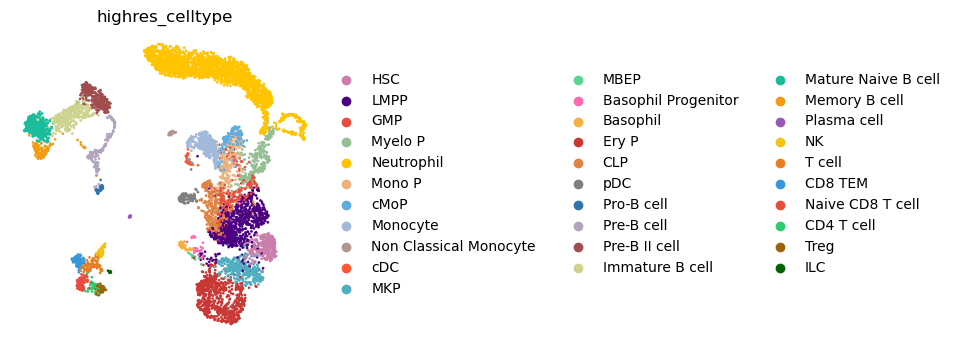

In [5]:
sc.pl.umap(adata, color=CELL_TYPE_COLUMN, frameon=False)

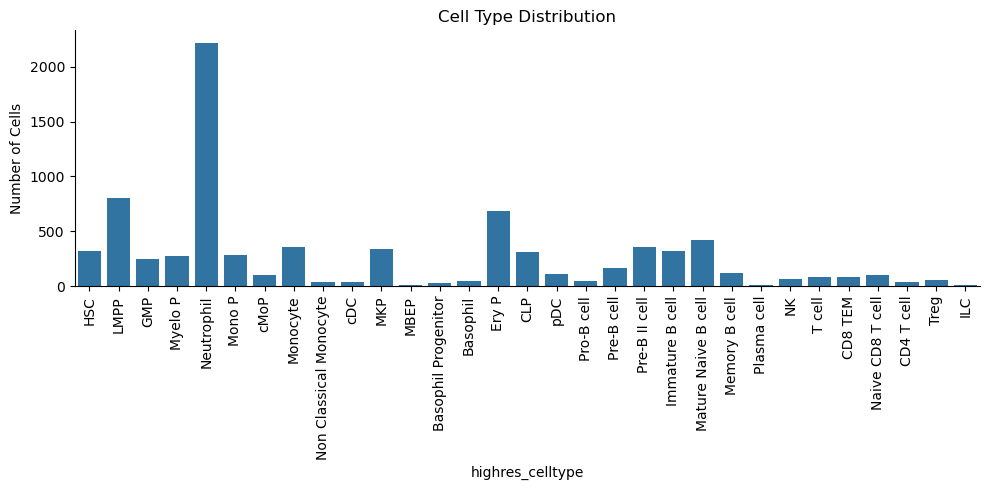

In [6]:
cell_type_counts = adata.obs[CELL_TYPE_COLUMN].value_counts()
plt.figure(figsize=(10, 5))
sns.barplot(x=cell_type_counts.index, y=cell_type_counts.values)
plt.xticks(rotation=90)
plt.title("Cell Type Distribution")
plt.ylabel("Number of Cells")
plt.tight_layout()
plt.show()

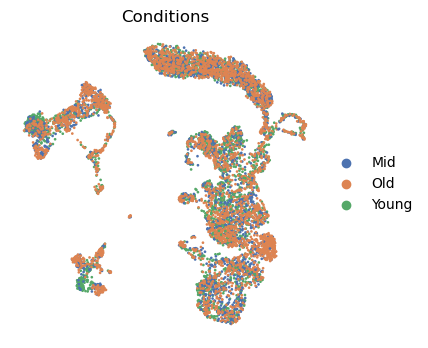

In [7]:
sc.pl.umap(adata, color=GROUPING_COLUMN, title="Conditions", frameon=False)

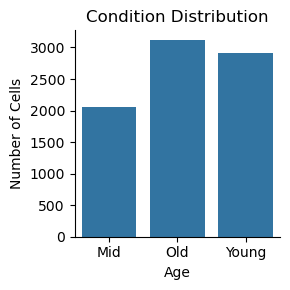

In [8]:
condition_counts = adata.obs[GROUPING_COLUMN].value_counts()
plt.figure(figsize=(3, 3))
sns.barplot(x=condition_counts.index, y=condition_counts.values)
plt.title("Condition Distribution")
plt.ylabel("Number of Cells")
plt.tight_layout()
plt.show()

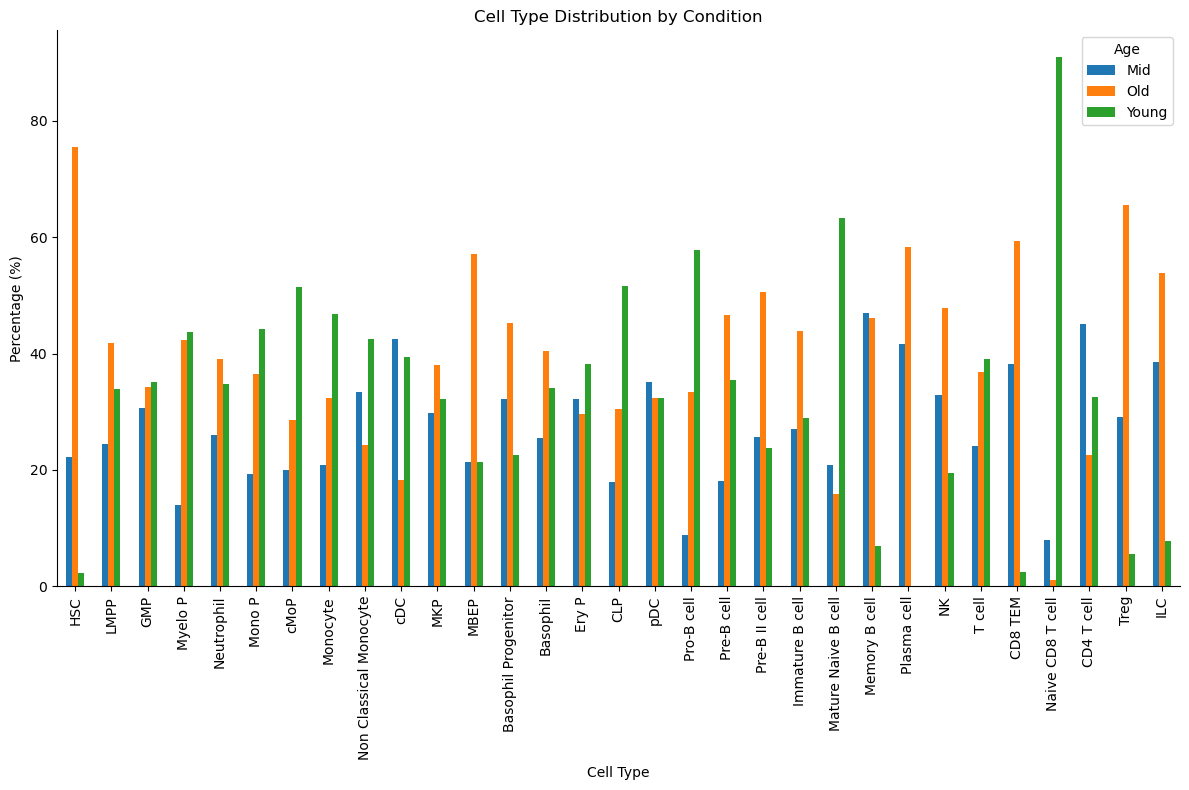

Cell types with >=75% bias toward one condition:
Age                     Mid        Old      Young
highres_celltype                                 
HSC               22.257053  75.548589   2.194357
Naive CD8 T cell   8.000000   1.000000  91.000000

These cell types might show disproportionate changes between conditions.


In [9]:
crosstab = (
    pd.crosstab(
        adata.obs[CELL_TYPE_COLUMN], adata.obs[GROUPING_COLUMN], normalize="index"
    )
    * 100
)

# Plot the distribution
ax = crosstab.plot(kind="bar", stacked=False, figsize=(12, 8))
ax.grid(False)
plt.xlabel("Cell Type")
plt.ylabel("Percentage (%)")
plt.title("Cell Type Distribution by Condition")
plt.legend(title=GROUPING_COLUMN)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Print extremes (cell types with high bias toward one condition)
bias_threshold = 75  # Percentage threshold for considering a cell type biased
biased_types = crosstab[(crosstab > bias_threshold).any(axis=1)]

if not biased_types.empty:
    print(f"Cell types with >={bias_threshold}% bias toward one condition:")
    print(biased_types)
    print("\nThese cell types might show disproportionate changes between conditions.")

## Preprocessing with Diffusion Maps

For Kompot to perform effectively, we need a good representation of cell state. Diffusion maps are an excellent choice because they:

1. Capture the intrinsic geometry of high-dimensional single-cell data
2. Preserve the continuous nature of cellular differentiation trajectories
3. Reduce technical noise while maintaining biological signal
4. Focus on global structure rather than local variations

We'll use Palantir's implementation of diffusion maps, which works directly with AnnData objects and provides a robust low-dimensional representation of cell states.

In [10]:
palantir.utils.run_diffusion_maps(adata, pca_key="X_pca_harmony", n_components=40);

## Running Differential Analysis with Kompot

Now we'll run the differential analysis using Kompot. We'll perform two types of analysis:

1. **Differential Abundance (DA)**: Identifies cell states that change in frequency between conditions
2. **Differential Expression (DE)**: Identifies genes that change in expression between conditions

### Understanding Kompot Parameters

For Differential Abundance:
- `groupby`: Column in adata.obs containing condition labels
- `condition1`/`condition2`: The conditions to compare (condition1 is the reference)
- `obsm_key`: The dimensionality reduction to use as cell state representation
- `log_fold_change_threshold`: The minimum log fold change to consider significant

For Differential Expression:
- `layer`: The expression data to use (normalized counts, log counts, etc.)
- `batch_size`: Can be set to process data in batches to reduce memory usage (0 means no batching)

### How Kompot Works

Kompot uses Gaussian processes to model the density of cells in each condition and then computes the log-fold change between these densities. For differential expression, it implements a statistical test based on the Mahalanobis distance, which is particularly sensitive to differences along continuous cell states and accounts for the covariance structure of the data.

In [11]:
# First, let's compute differential abundance between conditions
da_results = kompot.compute_differential_abundance(
    adata,  # AnnData object
    groupby=GROUPING_COLUMN,  # Column with condition labels
    condition1=CONDITIONS[0],  # Reference condition
    condition2=CONDITIONS[1],  # Comparison condition
    obsm_key=DIMENSIONALITY_REDUCTION,  # Cell state representation
)

[2025-10-01 19:37:51,533] [INFO    ] Condition 1 (Young): 2,917 cells
[2025-10-01 19:37:51,534] [INFO    ] Condition 2 (Old): 3,116 cells
[2025-10-01 19:37:51,536] [INFO    ] Fitting density estimator for condition 1...


[2025-10-01 19:38:19,834] [INFO    ] Fitting density estimator for condition 2...
[2025-10-01 19:38:33,384] [WARNING ] The normalization is only effective if the density was trained with d_method="fractal".
[2025-10-01 19:38:34,290] [WARNING ] The normalization is only effective if the density was trained with d_method="fractal".
[2025-10-01 19:38:40,146] [INFO    ] This run will have `run_id=0`.


In [12]:
# Now, compute differential expression between the conditions
de_results = kompot.compute_differential_expression(
    adata,  # AnnData object
    groupby=GROUPING_COLUMN,  # Column with condition labels
    condition1=CONDITIONS[0],  # Reference condition
    condition2=CONDITIONS[1],  # Comparison condition
    layer=LAYER_FOR_EXPRESSION,  # Expression data layer
    obsm_key=DIMENSIONALITY_REDUCTION,  # Cell state representation
    batch_size=0 # set to, e.g., 100 to batch cells and genes for lower memory demand
)

[2025-10-01 19:38:40,167] [INFO    ] Condition 1 (Young): 2,917 cells
[2025-10-01 19:38:40,167] [INFO    ] Condition 2 (Old): 3,116 cells
[2025-10-01 19:38:40,167] [INFO    ] Using 8090 of 8090 cells (100.0%)
[2025-10-01 19:38:40,478] [INFO    ] Preparing null distribution with null_genes=2000, null_seed=42
[2025-10-01 19:38:41,712] [INFO    ] Generated shuffled expression for 2000 null genes
[2025-10-01 19:38:46,602] [INFO    ] Fitting expression estimator for condition 1...
[2025-10-01 19:38:54,331] [INFO    ] Fitting expression estimator for condition 2...
[2025-10-01 19:39:15,036] [INFO    ] Landmark storage skipped (store_landmarks=False). Compute with store_landmarks=True to enable landmark reuse.
[2025-10-01 19:39:47,515] [INFO    ] Using 5,000 landmarks for Mahalanobis computation
[2025-10-01 19:40:07,592] [INFO    ] Computing FDR statistics from null distribution
[2025-10-01 19:40:09,205] [INFO    ] FDR analysis complete: 393/16285 genes significantly DE at FDR < 0.05
[2025-10

## Visualizing Differential Abundance Results

Now that we've computed differential abundance between conditions, let's visualize the results.

### What to Look For in the Visualizations

1. **Direction of Change**: "up" means a cell state is more abundant in the second condition (Old) compared to the reference (Young), while "down" means less abundant.

2. **Log Fold Change Scale**: 
   - Values near 0 indicate similar abundance across conditions
   - Positive values show enrichment in the second condition (Old)  
   - Negative values show depletion in the second condition (Old)

3. **Spatial Patterns**: Look for regions or clusters in the UMAP showing consistent changes - these represent biologically meaningful shifts in cell populations.

4. **Cell Type Correlations**: Check if specific cell types are consistently changing in abundance, which can reveal lineage-specific effects.

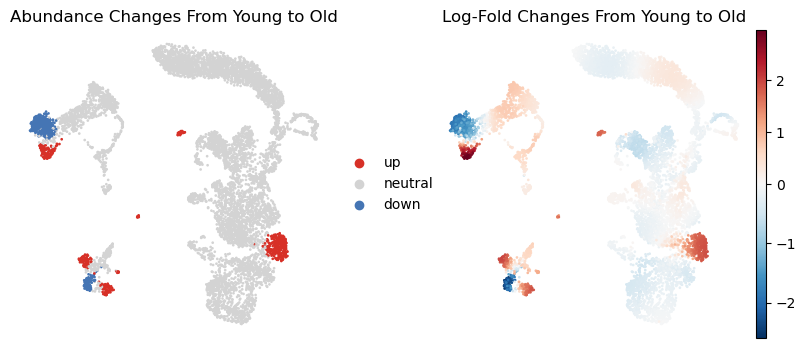

In [13]:
sc.pl.embedding(
    adata,
    "umap",
    color=[
        "kompot_da_Young_to_Old_lfc_direction",
        "kompot_da_Young_to_Old_lfc",
    ],
    title=["Abundance Changes From Young to Old", "Log-Fold Changes From Young to Old"],
    color_map="RdBu_r",
    vcenter=0,
    frameon=False,
)

We can use the kompot wrapper of `scanpy.pl.embedding` to color and subset by different criteria. Here we subset to cell states that are significantly differentially expressed by passing our criteria `{"kompot_da_log_fold_change_direction_Young_to_Old":["up", "down"]}` to the `groups` parameter.

[2025-10-01 19:40:14,760] [INFO    ] Selected 1,090 cells out of 8,090 total cells.


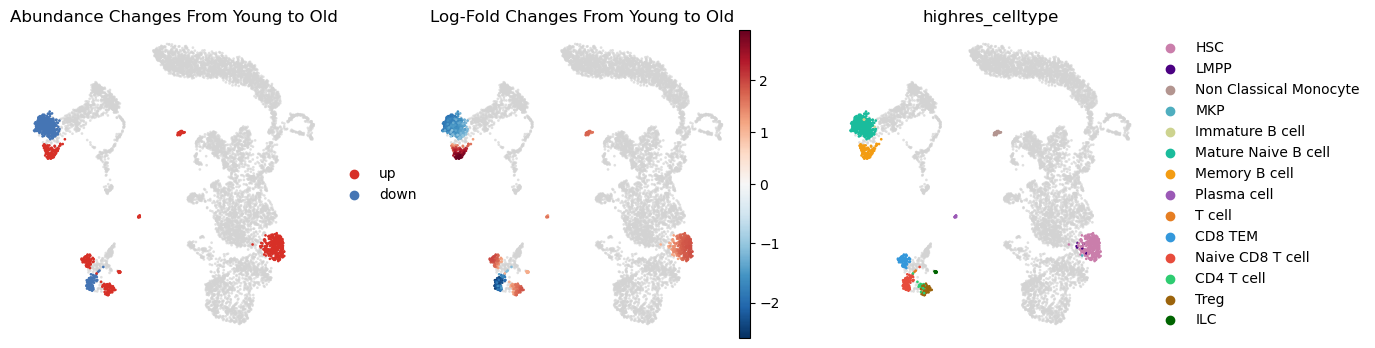

In [14]:
kompot.plot.embedding(
    adata,
    "umap",
    color=[
        "kompot_da_Young_to_Old_lfc_direction",
        "kompot_da_Young_to_Old_lfc",
        CELL_TYPE_COLUMN
    ],
    title=["Abundance Changes From Young to Old", "Log-Fold Changes From Young to Old", CELL_TYPE_COLUMN],
    color_map="RdBu_r",
    vcenter=0,
    groups={"kompot_da_Young_to_Old_lfc_direction":["up", "down"]},
    frameon=False,
)

Instead of multiple colorings, you can also plot multiple subsets uing the `mgroups` parameter. Here we are plotting the cell types for up and down abundancy changes by passing a list of filter instructions to `mgroups`. We also provide `wspace` to increase spacing for the legends.

[2025-10-01 19:40:15,472] [INFO    ] Selected 595 cells out of 8,090 total cells.
[2025-10-01 19:40:15,535] [INFO    ] Selected 495 cells out of 8,090 total cells.


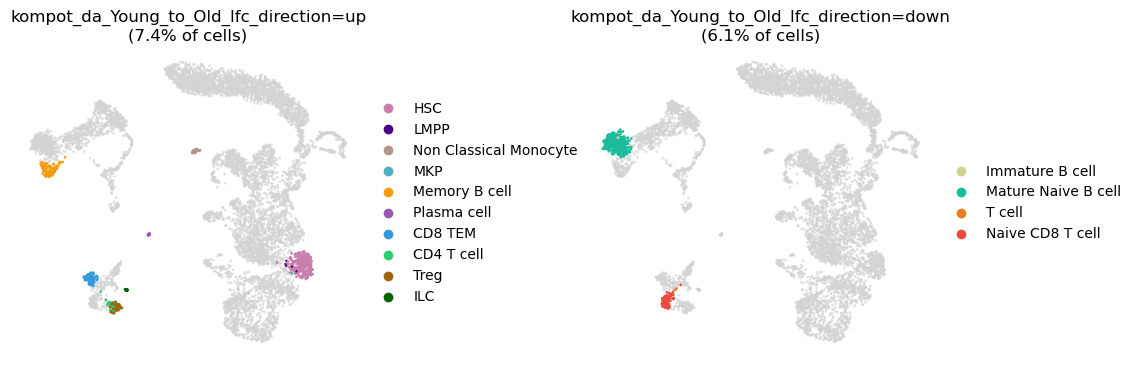

In [15]:
kompot.plot.embedding(
    adata,
    "umap",
    color=CELL_TYPE_COLUMN,
    mgroups=[{"kompot_da_Young_to_Old_lfc_direction":[d]} for d in ["up", "down"]],
    frameon=False,
    wspace=.5,
)

The cell volcano plot displays statistical significance versus effect size, with cells above the horizontal line and outside the vertical lines indicating significant changes. Points are colored by cell type to facilitate interpretation of which cell populations are changing. Consider adjusting thresholds for Posterior Tail Probabilities `ptp_threshold` and log-folc change `lfc_threshold` to more appropriate select outliers in your data. The run with `update_direction=True` to update the `adata.obs["kompot_da_log_fold_change_direction_Young_to_Old"]` column of your anndata.

[2025-10-01 19:40:15,939] [INFO    ] Found DA run info for run_id=-1
[2025-10-01 19:40:15,941] [INFO    ] Found lfc_key='kompot_da_Young_to_Old_lfc' from run info
[2025-10-01 19:40:15,941] [INFO    ] Found ptp_key='kompot_da_Young_to_Old_neg_log10_lfc_ptp' from run info
[2025-10-01 19:40:15,942] [INFO    ] Successfully inferred fields: {'lfc_key': 'kompot_da_Young_to_Old_lfc', 'ptp_key': 'kompot_da_Young_to_Old_neg_log10_lfc_ptp'}
[2025-10-01 19:40:15,943] [INFO    ] Using inferred thresholds - lfc_threshold: 1.0, ptp_threshold: 0.05


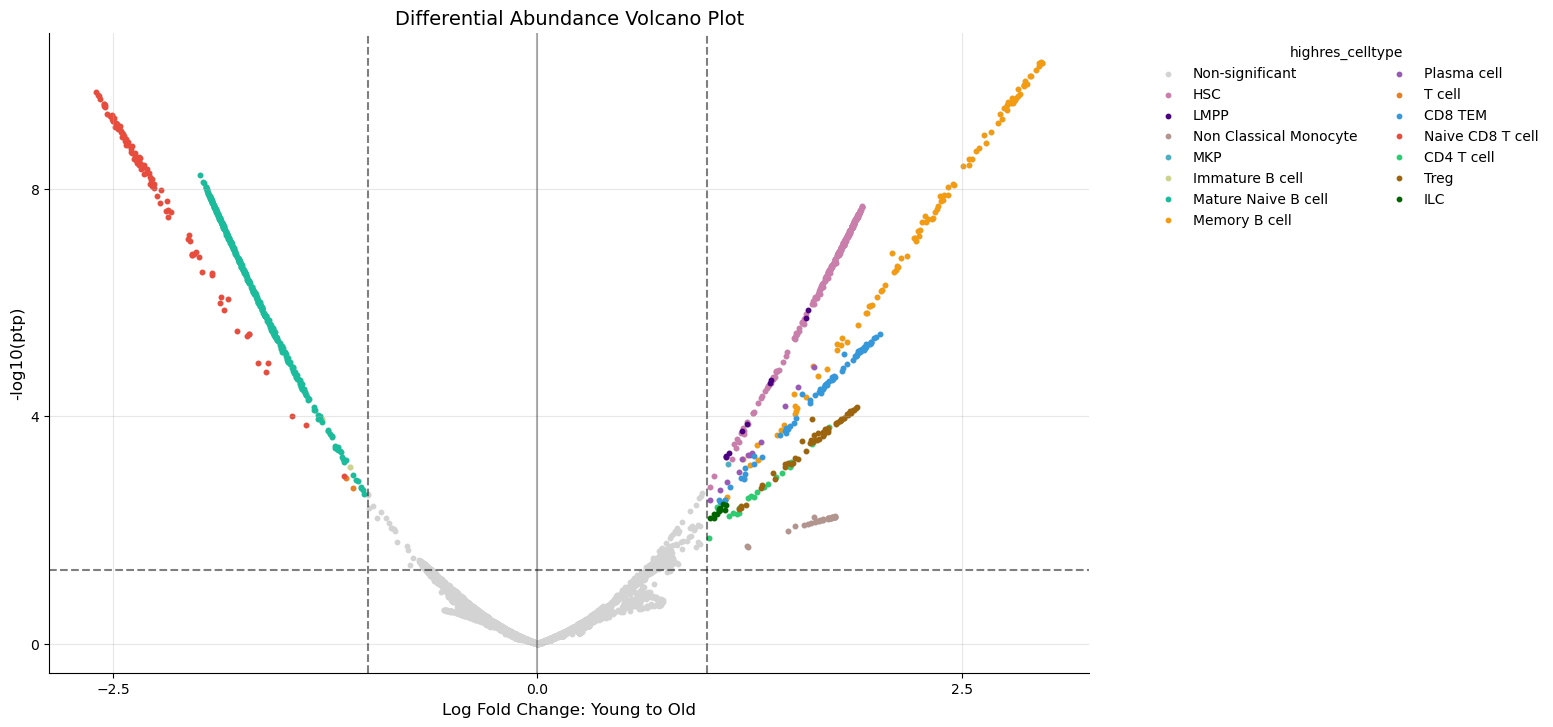

In [16]:
kompot.plot.volcano_da(adata, color=CELL_TYPE_COLUMN)

This plot shows the values of `adata.obs["kompot_da_log_fold_change_direction_Young_to_Old"]` representing significant changes in cell-state abundance, accumulated per group:

[2025-10-01 19:40:16,764] [INFO    ] Found DA run info for run_id=-1
[2025-10-01 19:40:16,765] [INFO    ] Found direction_key='kompot_da_Young_to_Old_lfc_direction' from run info
[2025-10-01 19:40:16,767] [INFO    ] Successfully inferred fields: {'direction_key': 'kompot_da_Young_to_Old_lfc_direction'}
[2025-10-01 19:40:16,768] [INFO    ] Using DA run 0 for direction_barplot: comparing Young to Old
[2025-10-01 19:40:16,768] [INFO    ] Creating direction barplot: comparing Young to Old
[2025-10-01 19:40:16,769] [INFO    ] Using fields - category_column: 'highres_celltype', direction_column: 'kompot_da_Young_to_Old_lfc_direction'


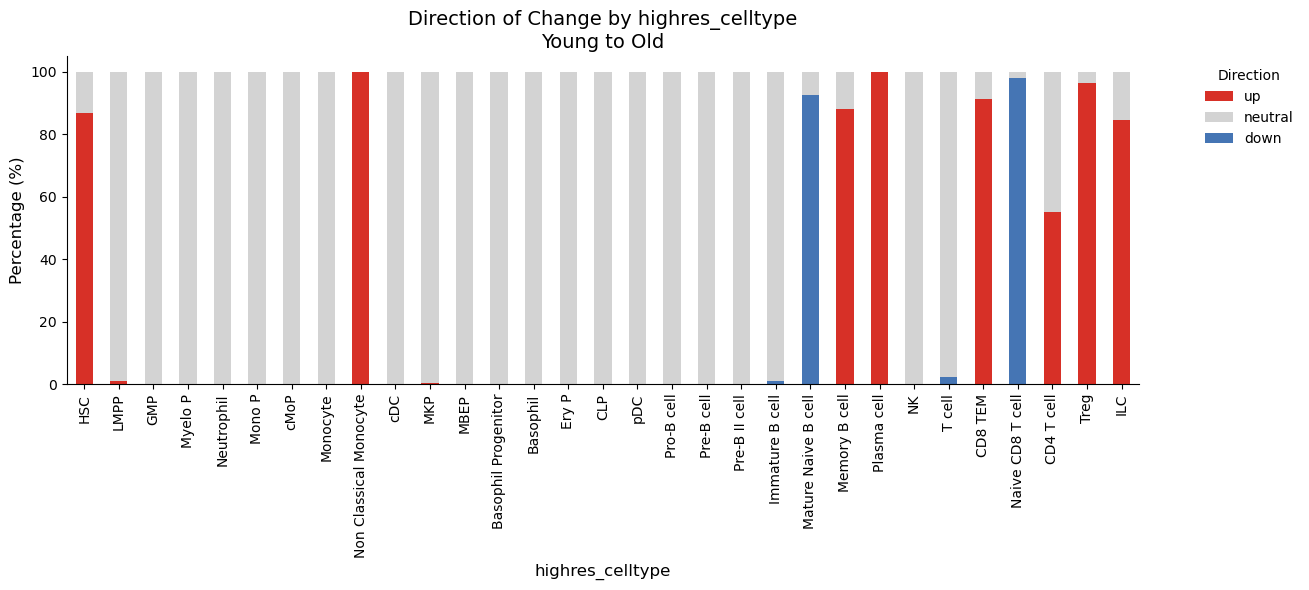

In [17]:
kompot.plot.direction_barplot(adata, category_column=CELL_TYPE_COLUMN)

To vizualize, effect size (log-fold change) and significance (-log10 ptp) split by the annotated groups, you can use the `kompot.plot.multi_volcano_da`. This function also allows to split volcano plots by any descrete column of your `adata.obs` through the `groupby` argument, and to make a `background_plot='kde'` or `background_plot='violin'` illustrating the distribution of cell along the x-axis:

[2025-10-01 19:40:17,163] [INFO    ] Found DA run info for run_id=-1
[2025-10-01 19:40:17,165] [INFO    ] Found lfc_key='kompot_da_Young_to_Old_lfc' from run info
[2025-10-01 19:40:17,165] [INFO    ] Found ptp_key='kompot_da_Young_to_Old_neg_log10_lfc_ptp' from run info
[2025-10-01 19:40:17,166] [INFO    ] Successfully inferred fields: {'lfc_key': 'kompot_da_Young_to_Old_lfc', 'ptp_key': 'kompot_da_Young_to_Old_neg_log10_lfc_ptp'}
[2025-10-01 19:40:17,167] [INFO    ] Using inferred thresholds - lfc_threshold: 1.0, ptp_threshold: 0.05
[2025-10-01 19:40:17,168] [INFO    ] Creating volcano plots for groups: Basophil, Basophil Progenitor, CD4 T cell, CD8 TEM, CLP, Ery P, GMP, HSC, ILC, Immature B cell, LMPP, MBEP, MKP, Mature Naive B cell, Memory B cell, Mono P, Monocyte, Myelo P, NK, Naive CD8 T cell, Neutrophil, Non Classical Monocyte, Plasma cell, Pre-B II cell, Pre-B cell, Pro-B cell, T cell, Treg, cDC, cMoP, pDC
[2025-10-01 19:40:18,035] [INFO    ] Color column 'highres_celltype' is i

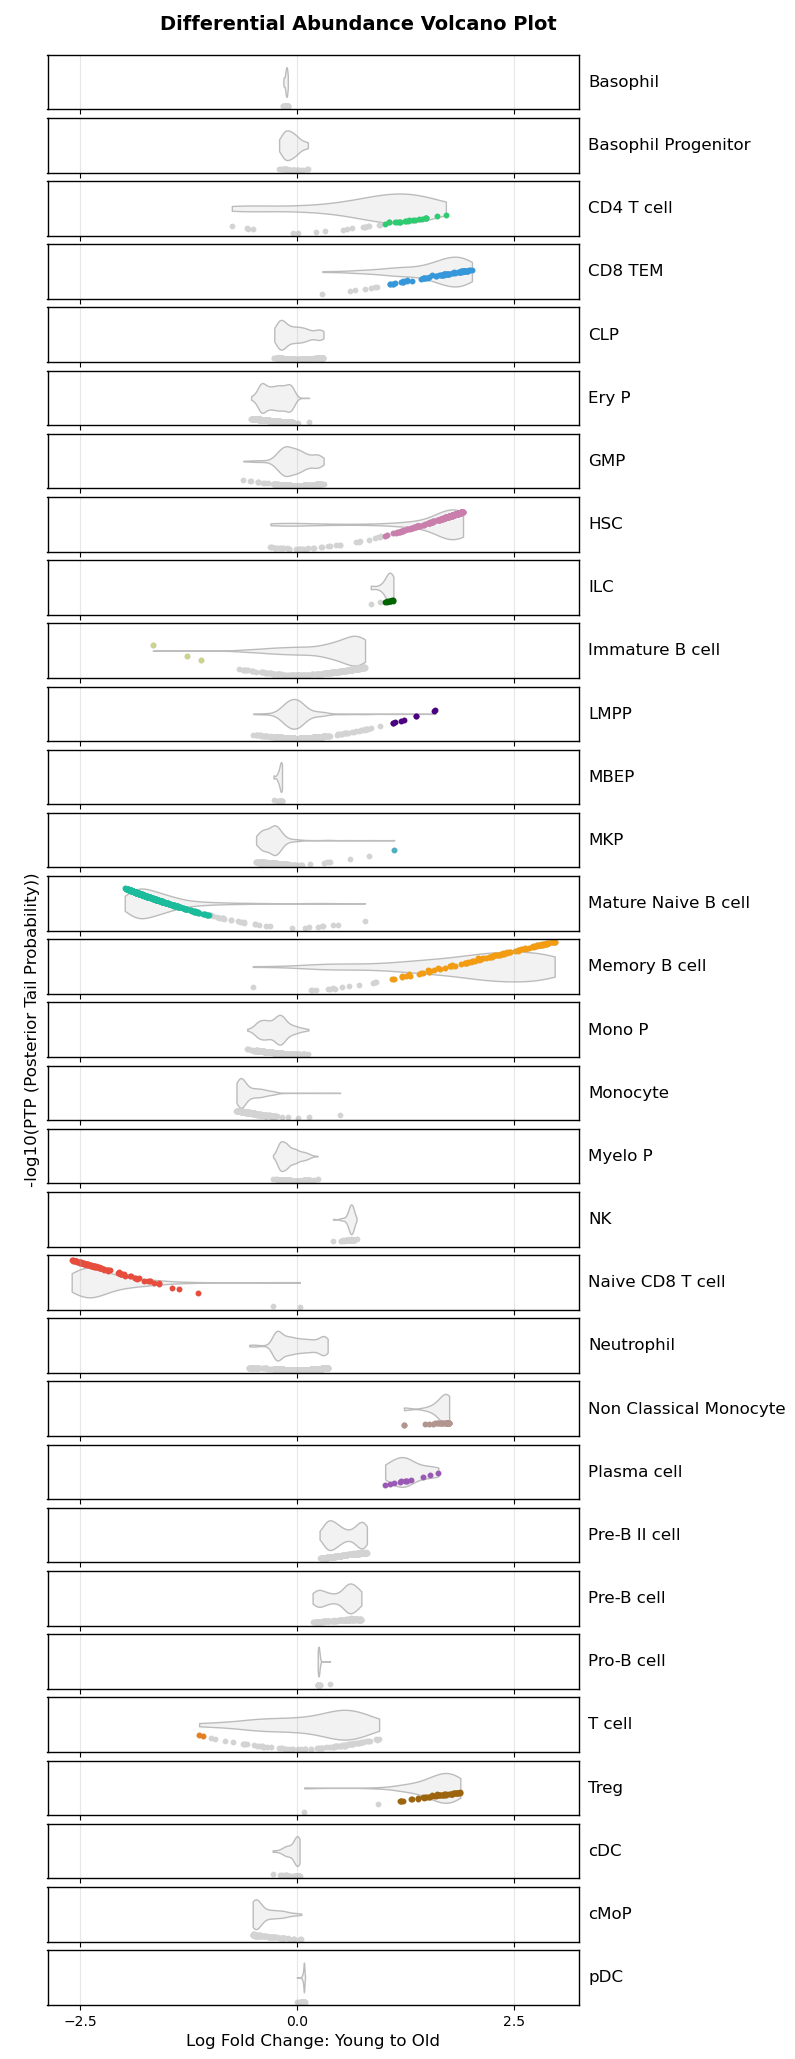

In [18]:
kompot.plot.multi_volcano_da(adata, groupby=CELL_TYPE_COLUMN, color=CELL_TYPE_COLUMN, background_plot='violin')

## Visualizing Differential Expression Results

Now let's examine the differential expression results to identify genes that change between conditions.

### Understanding the Results

The Kompot differential expression analysis produces several key metrics:

1. **Mean Log Fold Change**: The simple average log fold change across all cells
2. **Mahalanobis Distance**: A statistical measure that accounts for variance and covariance in the data

The Mahalanobis distance is particularly powerful because it:
- Accounts for the covariance structure of the data
- Is sensitive to changes in gene expression patterns
- Provides a robust measure of significance even for genes with complex expression patterns

### Volcano Plots

In a volcano plot:
- The x-axis shows the log fold change (effect size)
- The y-axis shows the Mahalanobis distance (statistical significance)
- Points in the upper right indicate genes upregulated in the second condition (Old)
- Points in the upper left indicate genes downregulated in the second condition (Old)

Let's first look at the top differentially expressed genes:

[2025-10-01 19:40:19,083] [INFO    ] Found DE run info for run_id=-1
[2025-10-01 19:40:19,084] [INFO    ] Found mean_lfc_key='kompot_de_Young_to_Old_mean_lfc' from run info
[2025-10-01 19:40:19,085] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Old_mahalanobis' from run info
[2025-10-01 19:40:19,086] [INFO    ] Successfully inferred fields: {'mean_lfc_key': 'kompot_de_Young_to_Old_mean_lfc', 'mahalanobis_key': 'kompot_de_Young_to_Old_mahalanobis'}
[2025-10-01 19:40:19,087] [INFO    ] Using DE run 0: comparing Young to Old
[2025-10-01 19:40:19,098] [INFO    ] Using data columns from var - lfc: 'kompot_de_Young_to_Old_mean_lfc', score: 'kompot_de_Young_to_Old_mahalanobis'
[2025-10-01 19:40:19,102] [INFO    ] Highlighting 393 genes marked as DE (232 up, 161 down)
[2025-10-01 19:40:19,114] [INFO    ] Labeling top 10 genes by score


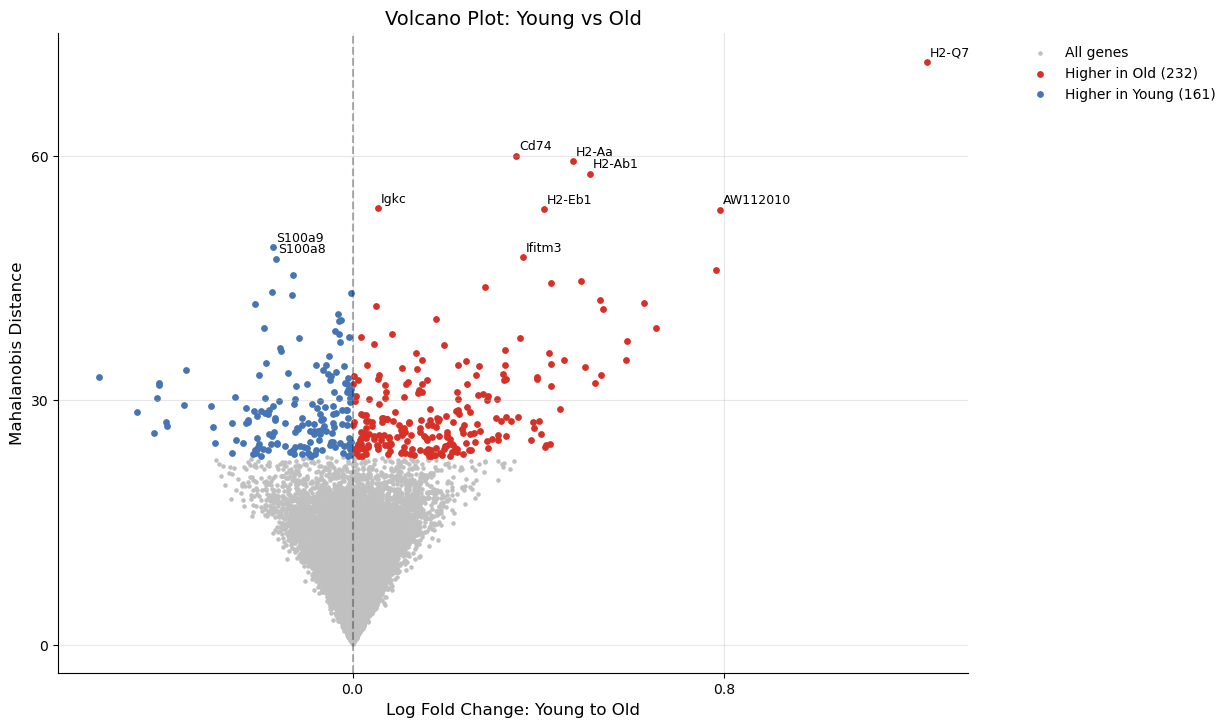

In [19]:
kompot.plot.volcano_de(adata)

Resulting gene-wise statistics cam be found in th `.var` dataframe. Here are tht top 20 genes sorted by significance:

In [20]:
adata.var.loc[:, adata.var.columns.str.contains("kompot_de")].sort_values("kompot_de_Young_to_Old_mahalanobis", ascending=False).head(20)

,kompot_de_Young_to_Old_mahalanobis,kompot_de_Young_to_Old_mean_lfc,kompot_de_Young_to_Old_mahalanobis_local_fdr,kompot_de_Young_to_Old_is_de
H2-Q7,71.517323,1.235066,0.014892,True
Cd74,60.021452,0.352121,0.014892,True
H2-Aa,59.371135,0.473756,0.014892,True
H2-Ab1,57.808982,0.511123,0.014892,True
Igkc,53.604112,0.054009,0.014892,True
H2-Eb1,53.403829,0.411752,0.014892,True
AW112010,53.386235,0.791367,0.014892,True
S100a9,48.765184,-0.170317,0.014892,True
Ifitm3,47.585813,0.367545,0.014892,True
S100a8,47.372815,-0.165121,0.014892,True


Function that provides provides plot for imputed expressions of both conditions and the fold changes. Here we show a gene with high significance but low mean log-fold change showing that some cell ppopulations show up and others down regulation, canceling out ion the mean:

[2025-10-01 19:40:19,384] [INFO    ] Found DE run info for run_id=-1
[2025-10-01 19:40:19,385] [INFO    ] Found mean_lfc_key='kompot_de_Young_to_Old_mean_lfc' from run info
[2025-10-01 19:40:19,386] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Old_mahalanobis' from run info
[2025-10-01 19:40:19,387] [INFO    ] Successfully inferred fields: {'mean_lfc_key': 'kompot_de_Young_to_Old_mean_lfc', 'mahalanobis_key': 'kompot_de_Young_to_Old_mahalanobis'}
[2025-10-01 19:40:19,387] [INFO    ] Using DE run 0: comparing Young to Old
[2025-10-01 19:40:19,388] [INFO    ] Using fields for gene expression plot - lfc_key: 'kompot_de_Young_to_Old_mean_lfc', score_key: 'kompot_de_Young_to_Old_mahalanobis'
[2025-10-01 19:40:19,388] [INFO    ] Using layer 'logged_counts' inferred from run information
[2025-10-01 19:40:19,390] [INFO    ] Using condition1 imputed layer 'kompot_de_Young_imputed' for 'Young'
[2025-10-01 19:40:19,390] [INFO    ] Using condition2 imputed layer 'kompot_de_Old_imputed' for

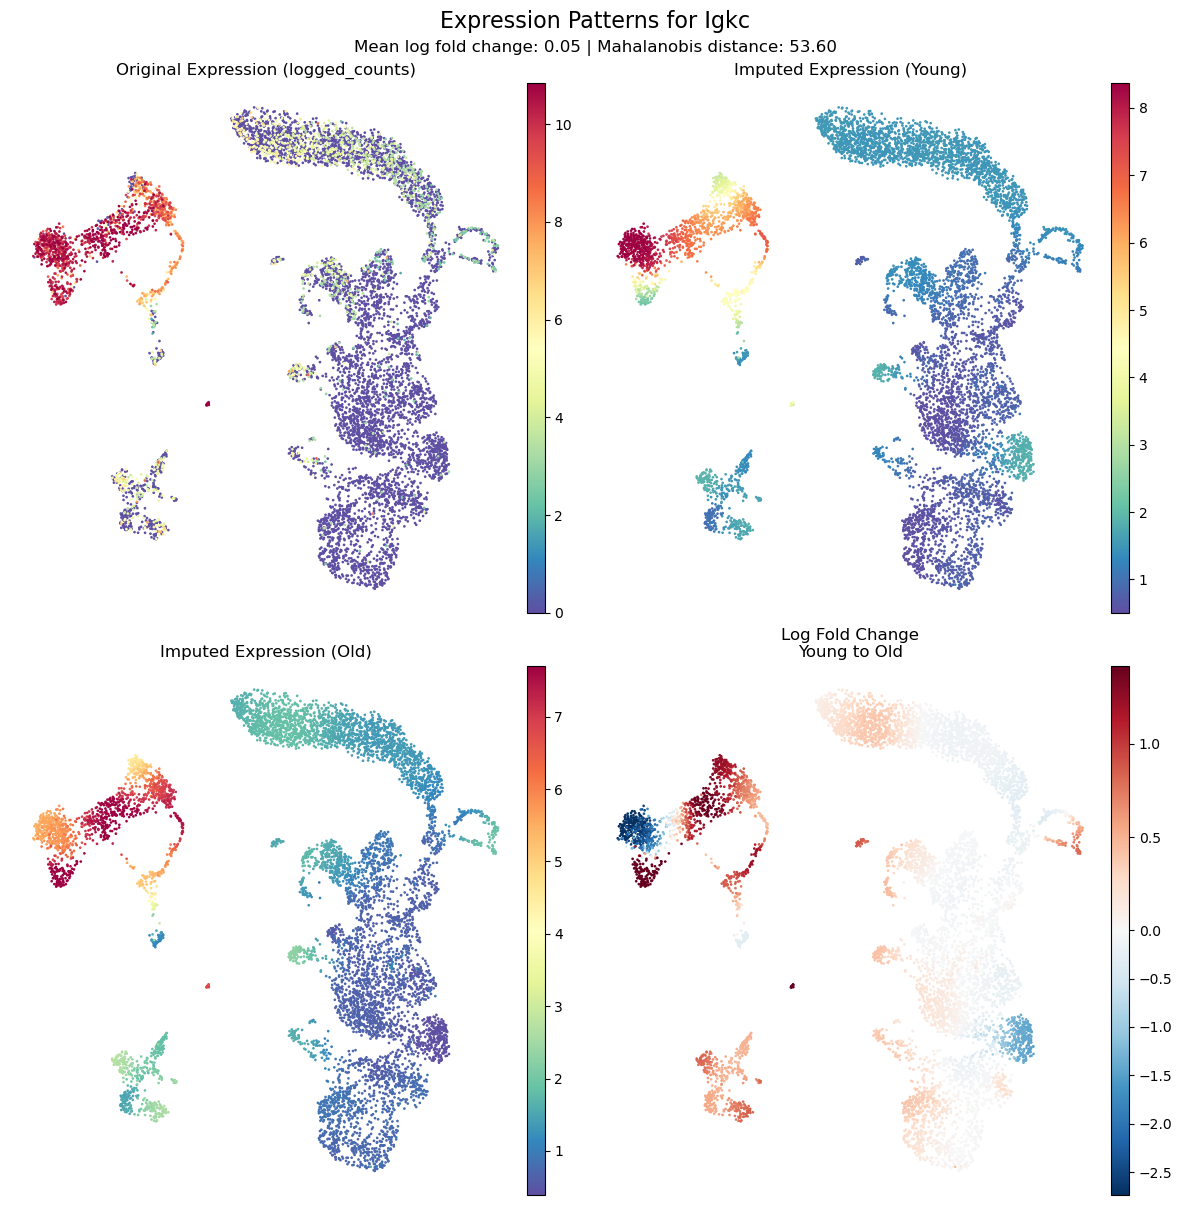

In [21]:
kompot.plot.plot_gene_expression(adata, gene="Igkc", vmin="p2", vmax="p98", frameon=False)

Tool to show gene-set enrichments, here, e.g., for all genes above the defaulkt siginificance threshold.

In [23]:
gene = adata.var["kompot_de_Young_to_Old_mahalanobis"].sort_values(ascending=False).head(20).index
report = kompot.plot.StringDBReport(gene, species_id=10090, include_enrichment=True)
report

Gene,Resource Links
H2-Q7,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene
Cd74,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene
H2-Aa,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene
H2-Ab1,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene
Igkc,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene
H2-Eb1,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene
AW112010,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene
S100a9,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene
Ifitm3,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene
S100a8,STRING DB | BioGRID | Reactome | GeneCards | UniProt | MGI | NCBI Gene


# Saving Results

## 1. Optionally: Remove large data layers
These layers contain the imputed expresssion values for all genes, cell,s and conditions plus the fold changes and take up a lot of disk space. If you do not want to preserve them for later plotting in the `plot_gene_expression` or downstream analysis, you can use the cleanup utility to reduce the object size:

In [24]:
kompot.cleanup(adata)

[2025-10-01 20:36:37,229] [INFO    ] Cleaning up all 1 run(s)
[2025-10-01 20:36:37,243] [INFO    ] Cleaned up 3 field(s) from run 0:
[2025-10-01 20:36:37,244] [INFO    ]   layers (3 field(s)):
[2025-10-01 20:36:37,245] [INFO    ]     - kompot_de_Young_imputed
[2025-10-01 20:36:37,245] [INFO    ]     - kompot_de_Old_imputed
[2025-10-01 20:36:37,246] [INFO    ]     - kompot_de_Young_to_Old_fold_change
[2025-10-01 20:36:37,246] [INFO    ] Total: Cleaned up 3 field(s) across 1 run(s)


## 2. Save Results

In [25]:
adata.write_h5ad("../data/murine_bone_marrow_aging_processed.h5ad")

## Biological Interpretation of Results

Now that we've identified differential abundance and expression patterns, let's interpret what these changes mean biologically.

### Key Findings

1. **Cell Type Changes with Age**:
   - HSCs (hematopoietic stem cells) show significantly increased abundance in Old to. Young mice
   - Naive CD8 T cells are predominantly found in Young mice
   - These findings align with previous studies showing HSC expansion but functional decline with age

2. **Gene Expression Changes**:
   - MHC class II genes (H2-Q7, H2-Q6, Cd74, H2-Aa, H2-Ab1) are upregulated in Old mice, suggesting increased antigen presentation and immune activation
   - Antioxidant genes (S100a8, S100a9, Apoe) are higher in Young mice
   - Interferon-stimulated genes (Ifitm family) show age-related changes, indicating altered immune response

### Functional Implications

These findings suggest that aging:
- Alters the composition of the hematopoietic system
- Changes immune surveillance and response mechanisms
- May affect stem cell functionality despite increased numbers
- Leads to chronic low-grade inflammation (inflammaging)

### Next Steps

To further validate and extend these findings, consider:
1. Functional assays to test HSC capacity in different age groups
2. Flow cytometry validation of key markers
3. Pathway analysis of the differentially expressed genes
4. Single-cell trajectory analysis to understand developmental changes
5. Integration with epigenomic data to understand regulatory mechanisms

## Conclusion

Kompot has allowed us to identify both cell state abundance changes and gene expression differences between Young and Old mice. The Mahalanobis distance-based approach provides sensitive detection of changes along continuous cell states, capturing biological signals that might be missed by traditional discrete methods.

For more details on Kompot parameters, methods, and applications, refer to the [complete documentation](https://kompot.readthedocs.io).